In [98]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [99]:
# read in all the words
words = open('../names.txt', 'r').read().splitlines()

In [100]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

# stoi maps character to integers
# itos maps integers to characters

In [101]:
# build the dataset

def build_dataset(words):
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

    return torch.tensor(X), torch.tensor(Y)

# What happens here is that we have a window of length block_size. We move the window across the window across
# the name to get all the possible contexts of length block_size. For each of these, we assign the label as the 
# next character. 

import random
random.seed(42)
random.shuffle(words)

# We choose n1 so that its 80% of the words
n1 = int(0.8*len(words))
# n2 is chosen to be 90% of the words
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [102]:
g = torch.Generator().manual_seed(2147483647)

# Initialize the look-up table
C = torch.randn((27,2), generator=g)

# Initialize the hidden layer weights and biases
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)

# Initialize the final layer weights and biases
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
paramters = [C, W1, b1, W2, b2]

In [103]:
for p in paramters:
    p.requires_grad = True

In [104]:
# Candidate learning rates on exponential scale
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [105]:
lri = []
lossi = []

for i in range(1000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))


    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])

    # backward pass
    for p in paramters:
        p.grad = None
    loss.backward()

    # update

    # choose learning rate
    lr = lrs[i]
    for p in paramters:
        p.data += -lr * p.grad

    # track stats
    lri.append(lr)
    lossi.append(loss.item())

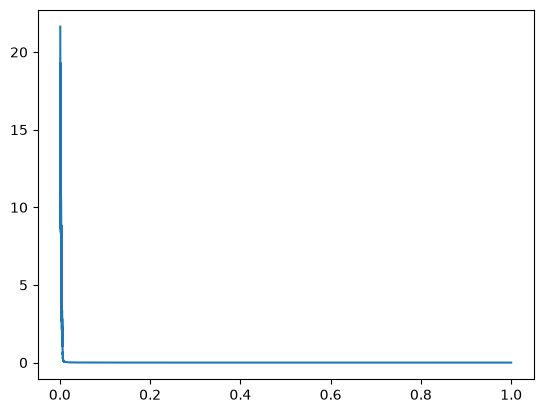

In [106]:
plt.plot(lri, lossi)

In [107]:
# Evaluate actual loss
emb = C[Xte]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss

tensor(13.8390, grad_fn=<NllLossBackward0>)